In [31]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [32]:
np.random.seed(42)

X = np.linspace(0, 1, 30)
y = np.sin(2 * np.pi * X) + np.random.normal(0, 0.2, 30)

X = X.reshape(-1, 1)

In [33]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42
)

In [34]:
degrees = [1, 4, 15]
x_plot = np.linspace(0, 1, 500).reshape(-1, 1)

plt.figure(figsize=(12, 6))

<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

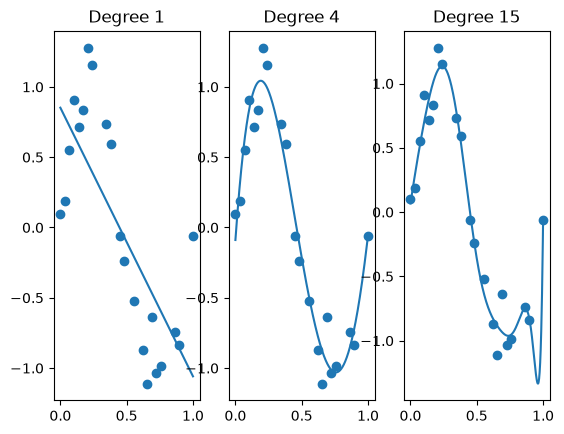

In [35]:
for i, degree in enumerate(degrees, 1):

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    y_plot = model.predict(x_plot)

    plt.subplot(1, 3, i)

    plt.scatter(X_train, y_train)
    plt.plot(x_plot, y_plot)

    plt.title(f"Degree {degree}")

In [36]:
degrees = range(1, 16)

train_errors = []
val_errors = []

In [37]:
for degree in degrees:

    model = make_pipeline(
        PolynomialFeatures(degree),
        LinearRegression()
    )

    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    val_pred = model.predict(X_val)

    train_error = mean_squared_error(y_train, train_pred)
    val_error = mean_squared_error(y_val, val_pred)

    train_errors.append(train_error)
    val_errors.append(val_error)

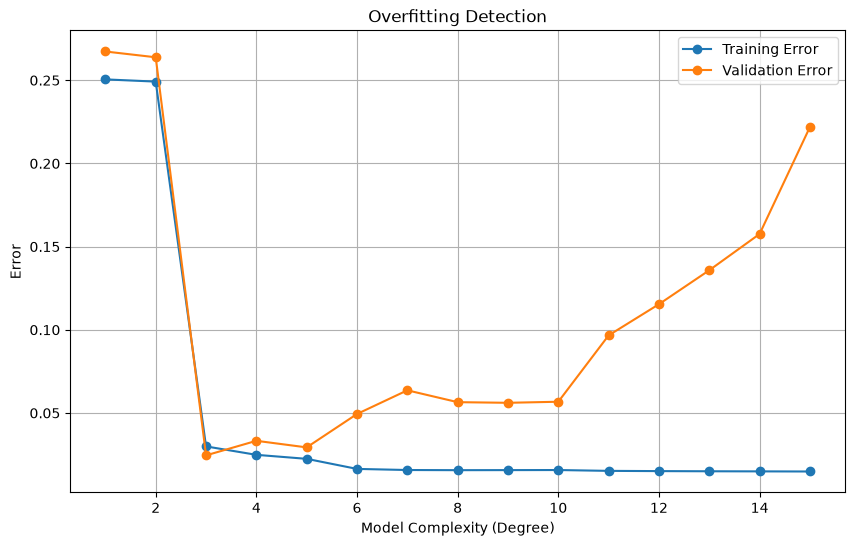

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(degrees, train_errors, marker="o", label="Training Error")
plt.plot(degrees, val_errors, marker="o", label="Validation Error")

plt.xlabel("Model Complexity (Degree)")
plt.ylabel("Error")
plt.title("Overfitting Detection")

plt.legend()
plt.grid()
plt.show()